In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import sobel

In [27]:
import glob

dataset_path = "/content/drive/MyDrive/train"
files = glob.glob(dataset_path + "/*.jpg")
print("The number of the files: " , len(files))

The number of the files:  200


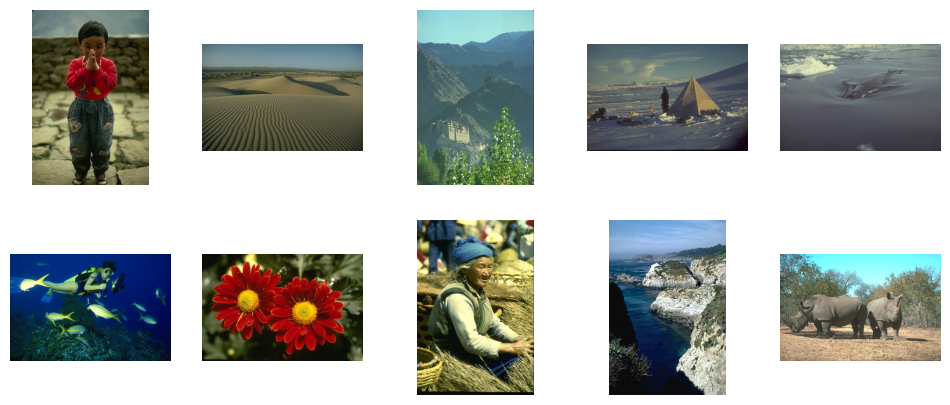

In [28]:
plt.figure(figsize = (12,5))

for i in range(10):
  img = cv2.imread(files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(2,5, i+1)
  plt.imshow(img)
  plt.axis("off")

In [29]:
image_root = "/content/drive/MyDrive/train"
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))


print("Number of images:", len(image_list))
if len(image_list) > 0:
    print("First image path:", image_list[0])
else:
    print("No images found. Check the folder path again.")

Number of images: 200
First image path: /content/drive/MyDrive/train/187029.jpg


Image shape: (481, 321)


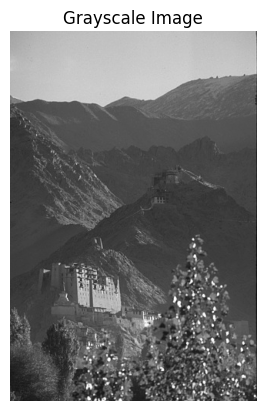

In [30]:
img = Image.open(image_list[2]).convert("L")
img_array = np.array(img)

print("Image shape:", img_array.shape)

plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

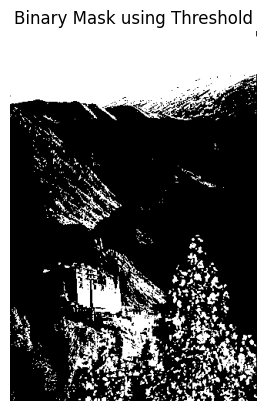

In [31]:
T = 120
mask = (img_array > T).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Binary Mask using Threshold")
plt.axis("off")
plt.show()

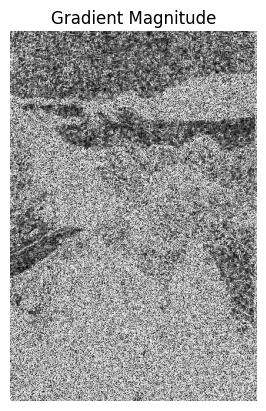

In [32]:
Gx = sobel(img_array, axis=1)
Gy = sobel(img_array, axis=0)

gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.show()

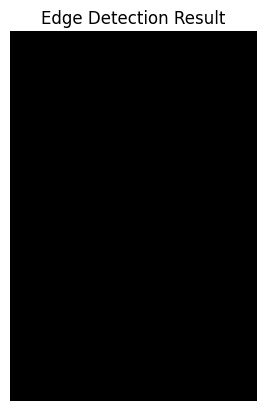

In [34]:
Te = 80

edges = (gradient_magnitude > Te).astype(np.uint8)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection Result")
plt.axis("off")
plt.show()

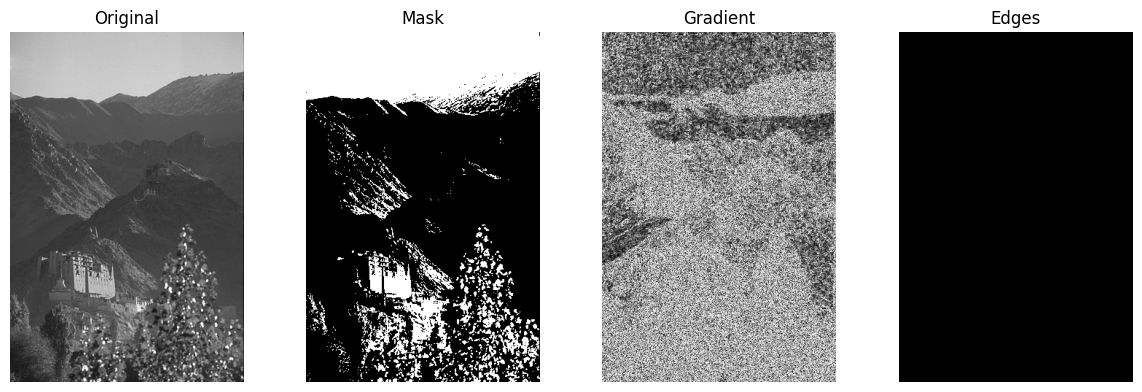

In [36]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))

image_list = sorted(image_list)

print("Total images found:", len(image_list))
print("Example:", image_list[0])



Total images found: 200
Example: /content/drive/MyDrive/train/100075.jpg


In [38]:
mask_folder = os.path.join(image_root, "generated_masks_New")
os.makedirs(mask_folder, exist_ok=True)

print("Masks will be saved in:", mask_folder)

Masks will be saved in: /content/drive/MyDrive/train/generated_masks_New


In [39]:
T = 120
print("Using threshold:", T)

Using threshold: 120


In [40]:
for img_path in image_list:
    # Load image and convert to grayscale
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)

    # Threshold-based mask generation
    mask = (img_array > T).astype(np.uint8) * 255

    # Create output file name
    img_name = os.path.basename(img_path)
    name_without_ext = os.path.splitext(img_name)[0]
    save_path = os.path.join(mask_folder, name_without_ext + "_mask.png")

    # Save mask
    Image.fromarray(mask).save(save_path)

print("All masks generated successfully.")

All masks generated successfully.


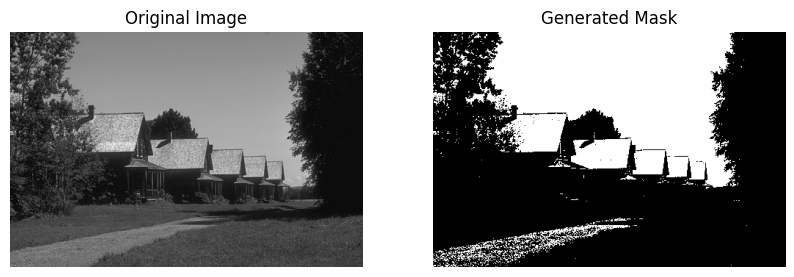

In [41]:
sample_img_path = image_list[100]

img = Image.open(sample_img_path).convert("L")
img_array = np.array(img)

mask_path = os.path.join(
    mask_folder,
    os.path.splitext(os.path.basename(sample_img_path))[0] + "_mask.png"
)
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Generated Mask")
plt.axis("off")

plt.show()